<a href="https://colab.research.google.com/github/lynnkaram/ai-course-projects/blob/main/project-3-particle-filtering/particle_filtering_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Particle Filtering for Soccer Player Tracking 🎯⚽

**Paper:** "No transfer of 3D-Multiple Object Tracking training on game performance in soccer: A follow-up study" (Romeas et al., Psychology of Sport & Exercise, 2024). The paper was published in the journal Psychology of Sport & Exercise.

Disclaimer: The Romeas et al. (2024) paper does not exactly use particle filtering.
I am using particle filtering as the class-related algorithm for this project,
because it models the same underlying idea of tracking multiple moving objects under uncertainty, which is the core cognitive skill measured in the paper.

## Introduction

Welcome to the third interactive tutorial:)

Here, we'll explore **particle filtering**, a powerful algorithm for tracking moving objects under uncertainty. This connects to a fascinating research paper that investigated whether training with 3D-Multiple Object Tracking (3D-MOT) could improve soccer players' actual game performance.

### The research question and why I chose this paper

The main idea of this paper is: **can training your brain to track moving objects in VR make you better at soccer?**

Soccer players constantly track teammates, opponents, and the ball. So logically, if you get better at tracking multiple moving targets in virtual reality, you might get better at tracking players on a real soccer field, right?

That's exactly what this study tested, and why I chose the paper! I myself played soccer for over 10 years back home in Dubai, but also in my undergraduate university teams in Madrid and in London. I found this paper very interesting as it combined both my extracurricular and academic interests. I think the hypothesis is a very interesting attempt at using emerging AI technologies in sports, and the concepts can also be linked to everything we learned in class too. So, I hope you enjoy this tutorial as I enjoyed working on it!

### What is 3D-Multiple Object Tracking (3D-MOT)?

Imagine wearing a VR headset and seeing 8 yellow spheres floating in 3D space:

1. **Start:** 4 of the 8 spheres briefly turn red (these are your targets)
2. **Tracking phase (8 seconds):** All spheres turn yellow and move around, bouncing off walls and each other
3. **Your task:** Identify which 4 spheres were the original targets

It's like an intense game of "keep your eye on the ball", but with 4 balls among 8 total! As players improved, the spheres moved faster.

### The study design

The participants are 62 elite youth soccer players (ages 13-18) from a professional academy. In two groups:
- **Training group (n=30):** Completed 3D-MOT training sessions over 10 weeks
- **Control group (n=32):** No cognitive training, just regular soccer practice

What they measured (before and after training):

1. **3D-MOT performance** - Did the training work? (manipulation check)
2. **Cognitive tests** - Did attention improve? (near transfer)  
3. **On-field soccer performance** - Did game performance improve? (far transfer - the main question). This was analzyed  by expert coaches via small-sided games (5v5 or 6v6), and scored on decision-making quality and skill execution.

### Results in the paper

**The manipulation check was a success**. The training group improved 3D-MOT scores by 56.4 cm/s. The control group only had 11.4 cm/s improvement. Therefore the training *worked*, they got better at tracking in VR. **Cognitive tests had no effect**, i.e. no improvement in attention tests between groups **On-field performance had no effect**. There was no improvement in decision-making or skill execution. Both groups performed similarly in games, and so better VR tracking ≠ better soccer performance.

### So why does this matter then?

1. **It challenges "brain training" claims**: Getting better at one task doesn't automatically transfer to other tasks, even when they seem related

2. **Task similarity isn't enough**: The 3D-MOT has predictable spheres, no deception, and is controlled VR environment. Then, in soccer, players have intentions and complex tactics, it's unpredictable. They are therefore actually more different than they appear.

3. **Specificity matters**. We don't say "practice makes perfect" for no reason... Want to get better at soccer? Practice it. Unfortunately, a general cognitive training might not be the shortcut we hoped for.

### Why particle filtering helps us understand this

Particle filtering is a computational algorithm that solves the tracking problem, i.e figuring out where moving objects are based on noisy observations.

Our tutorial will help you understand:
- How tracking works algorithmically (particle filtering does what the brain tries to do in 3D-MOT)
- Why tracking alone isn't enough for soccer (you also need decision-making, anticipation, motor execution)
- How task characteristics matter (different parameters = different difficulty = different skills needed)

By building and experimenting with a particle filter, you'll see why improving tracking in one context (VR spheres) doesn't automatically improve performance in another (real soccer).

### Connection to class content

This tutorial builds directly on concepts we've learned:

1. **Markov models:** Future state depends only on current state + velocity (Markov property)
2. **Particle filtering:** Monte Carlo approach using many samples (particles) to represent probability distributions
3. **Diffusion processes:** How uncertainty spreads over time as particles move
4. **Bayesian inference:** Combining predictions (prior) with observations (likelihood) to update beliefs (posterior)


In [ ]:
# Install required package (run this first)
!pip install filterpy -q

# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from filterpy.monte_carlo import systematic_resample
from numpy.random import randn, uniform
import scipy.stats

# ========== PARTICLE FILTER FUNCTIONS ==========
# note: right under each function I defined, there is an explanation of what it does, but also how it's connected to concepts we studied in class (in parentheses)
# + what the fuction takes as args and what it returns

def create_uniform_particles(x_range, y_range, N):
    """
    initialize N particles uniformly distributed over a 2D field

    (Prior distribution):
    - This represents maximum uncertainty; we have no idea where the object is
    - Uniform distribution is a "non-informative prior" in Bayesian terms
    - In the Romeas study, participants started each trial not knowing which spheres were targets (similar initial uncertainty)

    Args:
        x_range: (min, max) for x-coordinate (e.g. field width in meters)
        y_range: (min, max) for y-coordinate (e.g. field length in meters)
        N: Number of particles (more = better approximation, but slower)

    Returns:
        particles: Array of shape (N, 2) with random (x, y) positions
    """
    particles = np.empty((N, 2))
    particles[:, 0] = uniform(x_range[0], x_range[1], size=N)
    particles[:, 1] = uniform(y_range[0], y_range[1], size=N)
    return particles


def predict(particles, u, std, dt=1.):
    """
    Prediction step: move particles according to a motion model

    (Markov property & diffusion):
    - Markov assumption: next position depends only on current position + velocity
    - Diffusion: We add Gaussian noise to model uncertainty in movement
    - Like "Brownian" motion, particles spread out over time (this you might have also heard of before even though the term wasn't discussed in class)

    In soccer, a player running has some velocity, but that might change direction unpredictably. The noise models this uncertainty.

    Args:
        particles: current particle positions (N x 2 array)
        u: Control input (vx, vy) is the object's velocity
        std: process noise (σx, σy) = how unpredictable is the movement?
        dt: time step (default 1 second)

    Math: x(t+1) = x(t) + vx*dt + noise_x
          y(t+1) = y(t) + vy*dt + noise_y
    """
    N = len(particles)
    # Deterministic motion + stochastic noise (diffusion)
    particles[:, 0] += u[0] * dt + (randn(N) * std[0])
    particles[:, 1] += u[1] * dt + (randn(N) * std[1])


def update(particles, weights, z, R, landmarks):
    """
    Update step: reweight particles based on observations

    (Bayesian inference reminders):
    - This is the likelihood function P(observation | state)
    - Particles near the true position get high weights
    - This is exactly Bayes' rule: posterior ∝ prior × likelihood

    In the paper, participants had to identify which spheres were targets
    at the end of each trial, similar to this weighting process.

    Args:
        particles: current particle positions
        weights: current particle weights (will be modified in-place)
        z: Observations (e.g., measured distances to known landmarks)
        R: Measurement noise (how noisy are our sensors?)
        landmarks: Known reference points we measure distances from

    Math: weight_i = P(z | particle_i position)
    """
    for i, landmark in enumerate(landmarks):
        # Calculate distance from each particle to this landmark
        distance = np.linalg.norm(particles - landmark, axis=1)

        # Weight by likelihood: how probable is this observation given particle position?
        # Using Gaussian likelihood: exp(-(distance - z[i])^2 / (2*R^2))
        weights *= scipy.stats.norm(distance, R).pdf(z[i])

    weights += 1.e-300  # just to avoid division by zero
    weights /= sum(weights)  # Normalize so weights sum to 1 (the usual for probability distributions)


def estimate(particles, weights):
    """
    Compute the weighted mean to get our best guess of object position

    (Expected Value):
    - This is E[X] where X is position and weights are probabilities
    - Particles with high weights contribute more to the estimate
    - In statistics terms this is the mean of our posterior distribution

    Returns:
        pos: Estimated (x, y) position
    """
    return np.average(particles[:, 0:2], weights=weights, axis=0)


def neff(weights):
    """
    Compute effective sample size

    (Degeneracy problem)
    - This is a new concept but the idea is that this measures how "healthy" our particle set is
    - Low N_eff → most weight concentrated in few particles → time to resample

    Math: N_eff = 1 / Σ(w_i^2)
    - If all weights equal (1/N): N_eff = N (perfect)
    - If one weight = 1, rest = 0: N_eff = 1 (total degeneracy)

    Rule of thumb: resample when N_eff < N/2
    """
    return 1. / np.sum(np.square(weights))

# Just small prints to make sure everything ran
print("All particle filter functions defined\n")
print("The four key steps:")
print("1. Initialize → create_uniform_particles()")
print("2. Predict → predict()")
print("3. Update  → update()")
print("4. Resample → systematic_resample() [when neff() is low]")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
All particle filter functions defined

The four key steps:
1. Initialize → create_uniform_particles()
2. Predict → predict()
3. Update  → update()
4. Resample → systematic_resample() [when neff() is low]


## Visualizing initial uncertainty

Before we track anything, let's understand what particles represent. Each particle is a **hypothesis** about where the object might be.

### Key concept: representing uncertainty with samples

In Bayesian inference, we have probability distributions. But computing with continuous distributions is hard. Instead, particle filters use **Monte Carlo approximation**:

- Instead of P(x, y), we have N particles at positions {(x₁, y₁), (x₂, y₂), ..., (xₙ, yₙ)}
- The density of particles approximates the probability density
- More particles = better approximation (but more computation)

### The Romeas study connection

In the 3D-MOT task, participants saw 8 spheres. At the start of each trial, 4 spheres were briefly highlighted (these are the targets to track). Then, all 8 spheres moved for 8 seconds. Participants then had to identify which 4 were the original targets. This is like having 8 possible "particles" (spheres), but only 4 have high "weight" (they're the targets). Our particle filter does something similar :)

### Interactive element

In the next cell, you can modify `n_particles` to see how particle density affects our representation of uncertainty. Try values like 50, 300, or 1000.

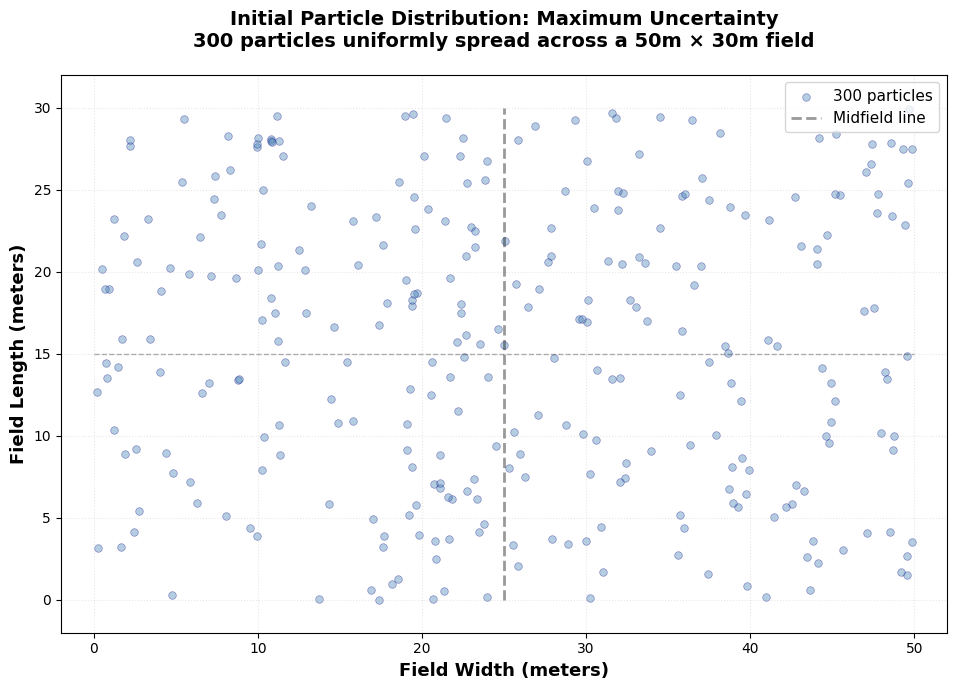


Interpretation:
  • Each blue dot represents one hypothesis about player location
  • Uniform spread = we have no idea where the player is
  • This is our prior distribution P(x) before any observations
  • Field size matches small-sided games from the Romeas study

Monte Carlo Approximation:
  • Continuous P(x,y) → 300 discrete samples
  • As n → ∞, particle distribution → true distribution
  • Trade-off: accuracy vs. computational cost

Experiment: Change n_particles above and re-run
  • With n=50, you should get sparse, less accurate representation
  • With n=1000, you should get dense, better approximation (but slower)


In [ ]:
# ========== Demo 1: Initial Uncertainty ==========

# Try changing these parameters
n_particles = 300    # Try: 50, 300, 1000. What changes?
field_width = 50     # meters (small-sided game field, like in Romeas study)
field_length = 30    # again this is in meters

# Create particles uniformly distributed across the field
particles = create_uniform_particles((0, field_width), (0, field_length), n_particles)

# Visualize
fig, ax = plt.subplots(figsize=(12, 7))

# Plot particles
ax.scatter(particles[:, 0], particles[:, 1], alpha=0.4, s=30, c='steelblue', edgecolors='navy', linewidth=0.5, label=f'{n_particles} particles')

# Add field markings for context (like a soccer field)
ax.plot([field_width/2, field_width/2], [0, field_length], 'k--', alpha=0.4, linewidth=2, label='Midfield line')
ax.plot([0, field_width], [field_length/2, field_length/2], 'k--', alpha=0.3, linewidth=1)

# Format plot
ax.set_xlim(-2, field_width + 2)
ax.set_ylim(-2, field_length + 2)
ax.set_xlabel('Field Width (meters)', fontsize=13, fontweight='bold')
ax.set_ylabel('Field Length (meters)', fontsize=13, fontweight='bold')
ax.set_title(f'Initial Particle Distribution: Maximum Uncertainty\n' +
             f'{n_particles} particles uniformly spread across a {field_width}m × {field_length}m field',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Interpretation
print(f"\nInterpretation:")
print(f"  • Each blue dot represents one hypothesis about player location")
print(f"  • Uniform spread = we have no idea where the player is")
print(f"  • This is our prior distribution P(x) before any observations")
print(f"  • Field size matches small-sided games from the Romeas study")
print(f"\nMonte Carlo Approximation:")
print(f"  • Continuous P(x,y) → {n_particles} discrete samples")
print(f"  • As n → ∞, particle distribution → true distribution")
print(f"  • Trade-off: accuracy vs. computational cost")

print(f"\nExperiment: Change n_particles above and re-run")
print(f"  • With n=50, you should get sparse, less accurate representation")
print(f"  • With n=1000, you should get dense, better approximation (but slower)")

## The heart of particle filtering → predict-update cycle

Another key concept here is that particle filtering alternates between two steps.

### 1. Predict (motion model)

Remember the Markov property? The future depends only on the present, not the past: x(t+1) = x(t) + velocity x Δt + noise. This is what `predict()` does. It moves each particle according to the motion model (velocity), then adds Gaussian noise to represent uncertainty in the motion. This is **diffusion**. Particles spread out over time.

Soccer players don't move perfectly predictably. They might change speed, change direction and stop suddenly. The noise models this unpredictability.

### 2. Update (measurement model)

This is Bayes' rule P(state | observation) ∝ P(observation | state) x P(state).

What the update step does:
- We measure distances to known landmarks (e.g., field corners, goal posts)
- Particles whose predicted position matches the measurement get high weights
- Particles far from the measurement get low weights
- This is the likelihood function P(z | x)

### 3. Resample (deal with degeneracy)

We briefly mentioned particle degeneracy in the code of cell 1. To elaborate it further, the idea is that over time, as we update particle weights based on observations, some particles end up with very high weights (they match the measurements well) while most get near-zero weights. This means we're wasting computation on particles that don't contribute to our estimate. We measure this with "effective sample size"; if we started with 200 particles but only 6 have meaningful weight, we're only using 3% of our computational budget effectively.

The solution is **systematic resampling**:
- Keep particles with high weights (duplicate them)
- Discard particles with low weights
- Reset all weights to 1/N

Now we have N "good" particles again :)

### Connection to the Romeas study

The 3D-MOT task required participants to **track** 4 moving spheres among 8 total (like our predict step), **identify** which ones were targets at the end (like our update step), **maintain attention** on multiple objects simultaneously.

Our particle filter does all three algorithmically. Each particle is like one "hypothesis" the brain might be considering about which sphere is which.

### In the next cell...

We'll run a complete simulation of tracking a moving soccer player. You'll see the predict-update-resample cycle in action, and how particles converge on the true position over time.

Simulation parameters:
  • Particles: 400
  • Process noise: (1.5, 1.5)
  • Measurement noise: 2.0


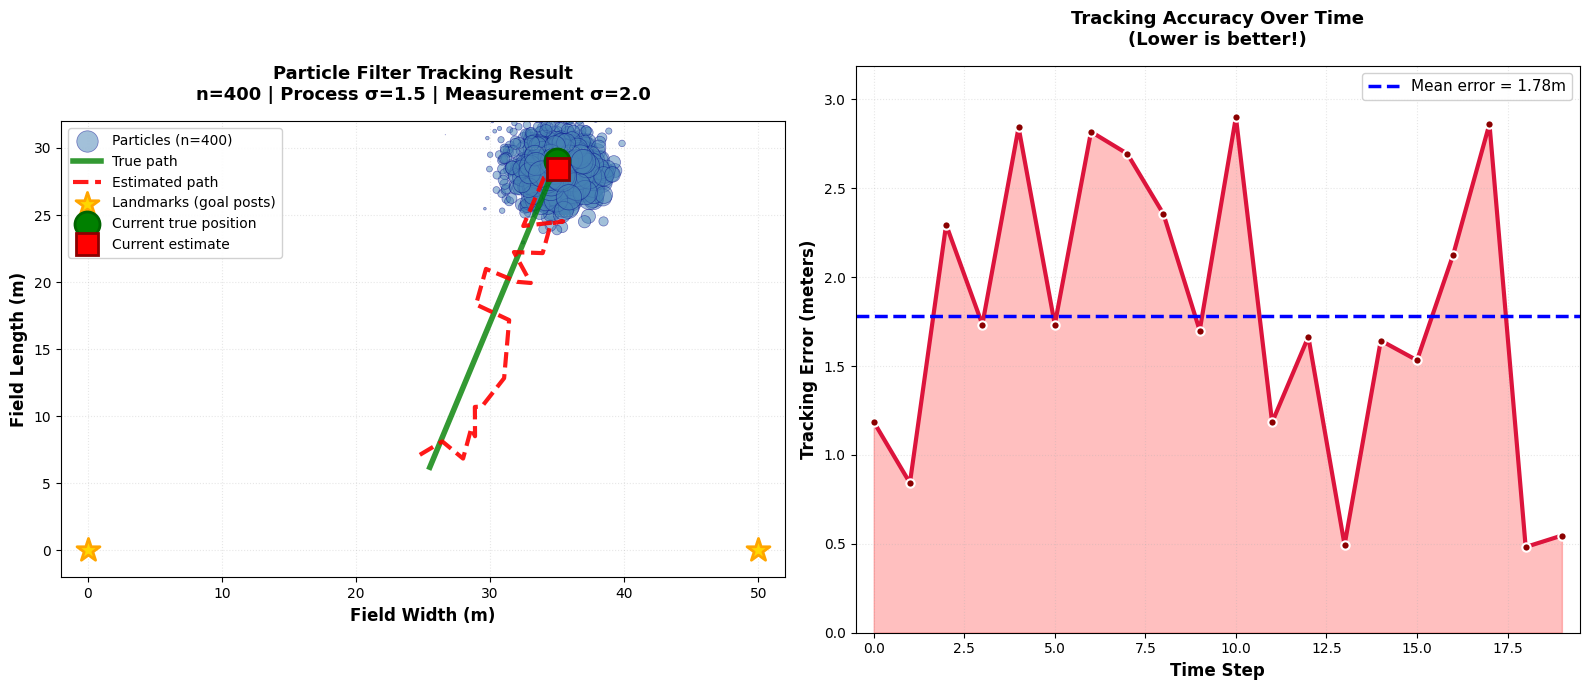


Interpreting the visualizations:
  • Left plot: Particles cluster around the true position (green circle)
    - Bigger dots = higher weight = more confident that the player is there
  • Right plot: Error fluctuates rather than smoothly converging
    - This is normal because the player is moving, creating dynamic uncertainty
    - Spikes occur during resampling or when measurements are noisy
    - Key insight here is that the mean error stays low (~1.78m) despite fluctuations


Tracking Performance Analysis:
  Mean error:        1.782 meters
  Std dev of error:  0.798 meters
  Max error:         2.899 meters (at step 10)
  Min error:         0.482 meters (at step 18)
  Final error:       0.547 meters

Connection to Romeas et al. (2024) study:
  • Study tracked players at visual speeds of ~100-150 cm/s
  • Our simulation: player moving at 130.0 cm/s
  • 3D-MOT improved tracking scores but no transfer to game performance
  • Why? Tracking alone isn't enough, we need decision-making, ant

In [ ]:
# ========== Demo 2: Complete Particle Filter Tracking ==========

# Try changing these parameters to explore how they affect tracking
n = 400                      # Number of particles (try: 100, 400, 1000)
process_noise = (1.5, 1.5)   # Motion uncertainty (try: (0.5,0.5), (1.5,1.5), (4.0,4.0))
measurement_noise = 2.0      # Sensor noise (try: 0.5, 2.0, 5.0)

print(f"Simulation parameters:")
print(f"  • Particles: {n}")
print(f"  • Process noise: {process_noise}")
print(f"  • Measurement noise: {measurement_noise}")

# Setup: Simulate tracking a soccer player moving across the field
np.random.seed(42)  # For reproducibility
field_size = (50, 30)

# Landmarks = known reference points (e.g., two goal posts)
landmarks = np.array([[0, 0], [50, 0]])  # Bottom-left and bottom-right corners

# True player trajectory (we'll track this)
true_positions = []
true_pos = np.array([25., 5.])  # Start at bottom-center of field
velocity = np.array([0.5, 1.2])  # Moving up-right (diagonal run)

# Initialize particle filter
particles = create_uniform_particles((0, field_size[0]), (0, field_size[1]), n)
weights = np.ones(n) / n  # All particles start with equal weight
estimates = []
particle_history = []  # Store particles for animation later

# Run simulation
n_steps = 20
for step in range(n_steps):
    # Ground truth: player actually moves
    true_pos += velocity
    true_positions.append(true_pos.copy())

    # Sensor: generate noisy distance measurements to landmarks
    z = np.array([np.linalg.norm(true_pos - lm) + randn() * measurement_noise
                  for lm in landmarks])

    # Step 1: Predict - Move particles according to motion model
    predict(particles, u=velocity, std=process_noise)

    # Step 2: Update - Reweight particles based on observations
    update(particles, weights, z, measurement_noise, landmarks)

    # Step 3: Resample - Avoid degeneracy
    if neff(weights) < n/2:  # Check if degeneracy is occurring
        indices = systematic_resample(weights)
        particles = particles[indices]
        weights.fill(1.0 / n)  # Reset weights after resampling

    # Step 4: Estimate - Compute best guess
    estimates.append(estimate(particles, weights))
    particle_history.append(particles.copy())

true_positions = np.array(true_positions)
estimates = np.array(estimates)

# ========== Visualization ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left plot: Tracking visualization (final state)
# Particle size proportional to weight (bigger = more likely)
particle_sizes = weights * n * 200
ax1.scatter(particles[:, 0], particles[:, 1], alpha=0.5, s=particle_sizes, c='steelblue', edgecolors='darkblue', linewidth=0.5, label=f'Particles (n={n})')

# True path (ground truth)
ax1.plot(true_positions[:, 0], true_positions[:, 1], 'g-', linewidth=4, label='True path', alpha=0.8, zorder=10)

# Estimated path (what our filter thinks)
ax1.plot(estimates[:, 0], estimates[:, 1], 'r--', linewidth=3, label='Estimated path', alpha=0.9, zorder=11)

# Landmarks (reference points for measurements)
ax1.scatter(landmarks[:, 0], landmarks[:, 1], c='gold', s=300, marker='*', label='Landmarks (goal posts)', edgecolors='orange', linewidths=2, zorder=12)

# Current positions
ax1.plot(true_positions[-1, 0], true_positions[-1, 1], 'go', markersize=18, label='Current true position', zorder=13, markeredgecolor='darkgreen', markeredgewidth=2)
ax1.plot(estimates[-1, 0], estimates[-1, 1], 'rs', markersize=16, label='Current estimate', zorder=13, markeredgecolor='darkred', markeredgewidth=2)

# Formatting
ax1.set_xlim(-2, field_size[0] + 2)
ax1.set_ylim(-2, field_size[1] + 2)
ax1.set_xlabel('Field Width (m)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Field Length (m)', fontsize=12, fontweight='bold')
ax1.set_title(f'Particle Filter Tracking Result\n' + f'n={n} | Process σ={process_noise[0]:.1f} | Measurement σ={measurement_noise:.1f}', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax1.set_aspect('equal')

# Right plot: Tracking error over time
errors = np.linalg.norm(true_positions - estimates, axis=1)
time_steps = np.arange(len(errors))
ax2.plot(time_steps, errors, linewidth=3, color='crimson', marker='o', markersize=6, markerfacecolor='darkred', markeredgecolor='white', markeredgewidth=1.5)
ax2.fill_between(time_steps, errors, alpha=0.25, color='red')
ax2.axhline(y=np.mean(errors), color='blue', linestyle='--', linewidth=2.5,label=f'Mean error = {np.mean(errors):.2f}m')
ax2.set_xlabel('Time Step', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tracking Error (meters)', fontsize=12, fontweight='bold')
ax2.set_title('Tracking Accuracy Over Time\n(Lower is better!)', fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax2.legend(fontsize=11, framealpha=0.9)
ax2.set_xlim(-0.5, len(errors) - 0.5)
ax2.set_ylim(0, max(errors) * 1.1)
plt.tight_layout()
plt.show()

# Plot explanations
print("\nInterpreting the visualizations:")
print("  • Left plot: Particles cluster around the true position (green circle)")
print("    - Bigger dots = higher weight = more confident that the player is there")
print("  • Right plot: Error fluctuates rather than smoothly converging")
print("    - This is normal because the player is moving, creating dynamic uncertainty")
print("    - Spikes occur during resampling or when measurements are noisy")
print("    - Key insight here is that the mean error stays low (~1.78m) despite fluctuations\n")

# ========== Detailed Analysis ==========

print(f"\nTracking Performance Analysis:")
print(f"  Mean error:        {np.mean(errors):.3f} meters")
print(f"  Std dev of error:  {np.std(errors):.3f} meters")
print(f"  Max error:         {np.max(errors):.3f} meters (at step {np.argmax(errors)})")
print(f"  Min error:         {np.min(errors):.3f} meters (at step {np.argmin(errors)})")
print(f"  Final error:       {errors[-1]:.3f} meters")

print(f"\nConnection to Romeas et al. (2024) study:")
print(f"  • Study tracked players at visual speeds of ~100-150 cm/s")
print(f"  • Our simulation: player moving at {np.linalg.norm(velocity)*100:.1f} cm/s")
print(f"  • 3D-MOT improved tracking scores but no transfer to game performance")
print(f"  • Why? Tracking alone isn't enough, we need decision-making, anticipation, and execution")

## Try it yourself, experiment with parameters

Now that you've seen the particle filter in action, try modifying the parameters to build intuition for how they affect tracking performance. Go back to the code cell above and try the following experiments.

**Experiment 1: Number of particles**

Change line 4 from `n = 400` to `n = 1000`. You'll see more particles gives better tracking accuracy. However, the improvement gets smaller as you add more particles. Going from 100 to 200 helps a lot, but going from 500 to 600 helps much less. This is the classic computational cost vs. accuracy trade-off.

**Experiment 2: Process noise (motion uncertainty)**

Change line 5 from `process_noise = (1.5, 1.5)` to `process_noise = (4.0, 4.0)`. Higher noise makes tracking harder because it models unpredictable player movement like sudden direction changes and speed variations. Real soccer players use feints and deception, so they'd have high process noise :)

**Experiment 3: Measurement noise (sensor reliability)**

Change line 6 from `measurement_noise = 2.0` to `measurement_noise = 5.0`. This simulates less reliable observations, like noisy GPS sensors. For reference, phone GPS typically has around 5m accuracy while professional tracking systems get down to 0.1m.

**Experiment 4: Movement direction**

Change line 23 from `velocity = np.array([0.5, 1.2])` to `velocity = np.array([2.0, 0.5])` to make the player run horizontally instead of diagonally. You can also try `(0.0, 2.0)` for a straight vertical run or `(1.0, 1.0)` for a 45° diagonal.

Some questions to think about are which parameter has the biggest effect on tracking accuracy? What happens if you set process_noise very low, like `(0.1, 0.1)`? Can you find parameter settings where the filter completely fails?

## Understanding Parameter Effects

One of the most important skills in machine learning is understanding how parameters affect performance.

In the next cell, we'll run side-by-side comparisons with different parameter settings. This will show you:
- How the number of particles affects accuracy
- How process noise models unpredictable movement
- How measurement noise models sensor reliability
- The exploration-exploitation trade-off (a key concept from MDPs and reinforcement learning)

Pay attention to which parameters have the biggest impact on tracking performance.

Running config 1/4: Low particles, low noise... Mean error: 0.526m
Running config 2/4: Many particles, low noise... Mean error: 0.664m
Running config 3/4: Many particles, high process noise... Mean error: 1.149m
Running config 4/4: Many particles, high measurement noise... Mean error: 2.356m


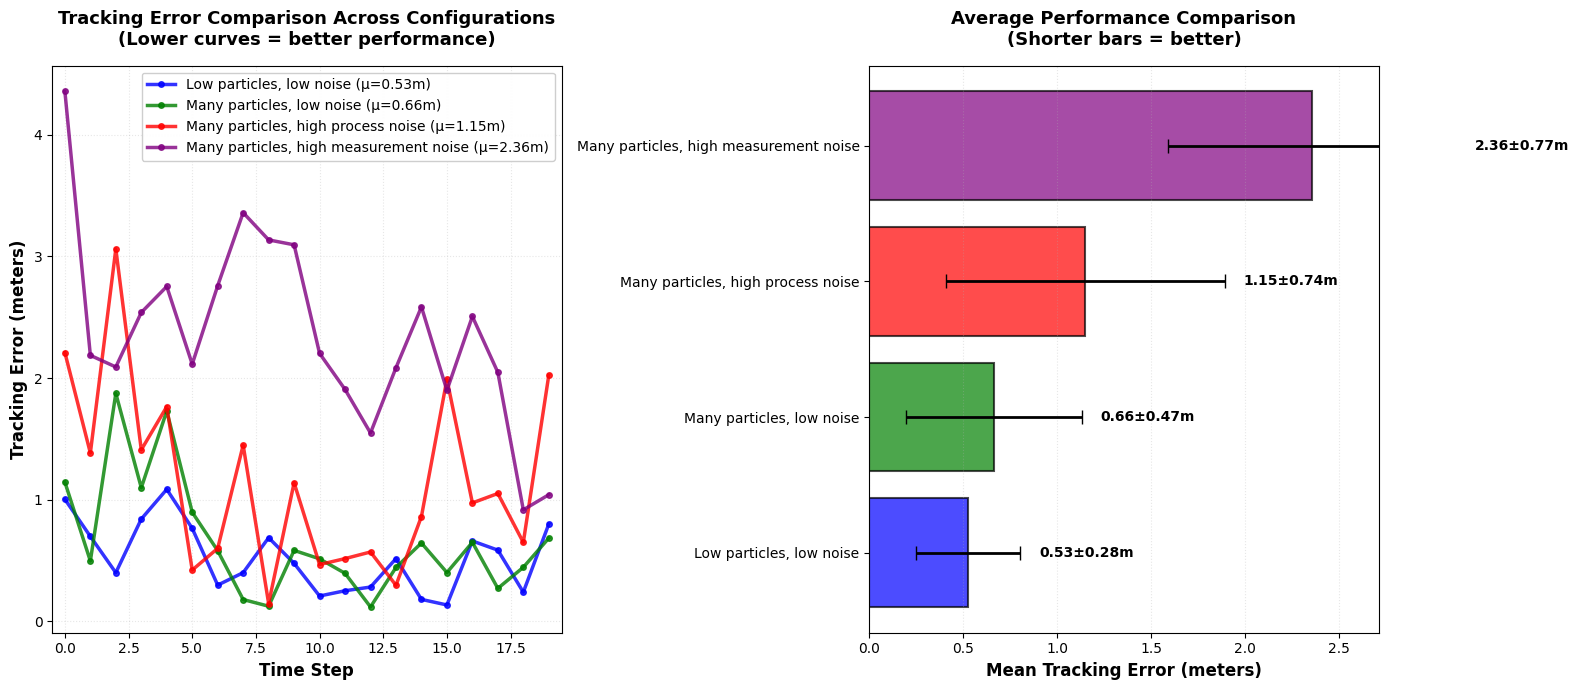


Detailed Performance Table:
Configuration                                 | Mean (m)   | Std (m)    | Max (m)   
------------------------------------------------------------------------------------------
n=150, σ_proc=0.5, σ_meas=1.0                 |     0.526 |     0.276 |     1.086
n=400, σ_proc=0.5, σ_meas=1.0                 |     0.664 |     0.466 |     1.873
n=400, σ_proc=3.0, σ_meas=1.0                 |     1.149 |     0.740 |     3.060
n=400, σ_proc=0.5, σ_meas=5.0                 |     2.356 |     0.768 |     4.354


In [ ]:
# ========== Demo 3: Compare Different Configurations ==========

# We'll run multiple simulations with different settings to see how parameters affect tracking performance.
# Define configurations to test:
configs = [
    {"n": 150, "process": 0.5, "measure": 1.0, "label": "Low particles, low noise", "color": "blue"},
    {"n": 400, "process": 0.5, "measure": 1.0, "label": "Many particles, low noise", "color": "green"},
    {"n": 400, "process": 3.0, "measure": 1.0, "label": "Many particles, high process noise", "color": "red"},
    {"n": 400, "process": 0.5, "measure": 5.0, "label": "Many particles, high measurement noise", "color": "purple"},
]

# You can add your own configuration
# E.g. uncomment and modify:
# configs.append({"n": 600, "process": 2.0, "measure": 2.0, "label": "My custom config", "color": "orange"})

results = []

# Run simulations for each configuration
for idx, config in enumerate(configs):
    print(f"Running config {idx+1}/{len(configs)}: {config['label']}...", end=" ")

    np.random.seed(42)  # Same random seed for fair comparison

    # Setup
    true_pos = np.array([25., 5.])
    velocity = np.array([0.5, 1.2])
    particles = create_uniform_particles((0, 50), (0, 30), config["n"])
    weights = np.ones(config["n"]) / config["n"]

    errors = []

    # Run filter
    for step in range(20):
        true_pos += velocity
        z = np.array([np.linalg.norm(true_pos - lm) + randn() * config["measure"] for lm in landmarks])
        predict(particles, velocity, (config["process"], config["process"]))
        update(particles, weights, z, config["measure"], landmarks)

        if neff(weights) < config["n"]/2:
            indices = systematic_resample(weights)
            particles = particles[indices]
            weights.fill(1.0 / config["n"])

        est = estimate(particles, weights)
        errors.append(np.linalg.norm(true_pos - est))

    results.append({
        "config": config,
        "mean_error": np.mean(errors),
        "std_error": np.std(errors),
        "errors": errors
    })

    print(f"Mean error: {np.mean(errors):.3f}m")

# ========== Visualization ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left plot: Error trajectories over time
for result in results:
    cfg = result['config']
    ax1.plot(result["errors"], linewidth=2.5, color=cfg['color'], label=f"{cfg['label']} (μ={result['mean_error']:.2f}m)", marker='o', markersize=4, alpha=0.8)

ax1.set_xlabel('Time Step', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tracking Error (meters)', fontsize=12, fontweight='bold')
ax1.set_title('Tracking Error Comparison Across Configurations\n(Lower curves = better performance)', fontsize=13, fontweight='bold', pad=15)
ax1.legend(loc='best', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
ax1.set_xlim(-0.5, 19.5)

# Right plot: Bar chart of mean errors
configs_labels = [r['config']['label'] for r in results]
mean_errors = [r['mean_error'] for r in results]
std_errors = [r['std_error'] for r in results]
colors = [r['config']['color'] for r in results]
bars = ax2.barh(range(len(results)), mean_errors, xerr=std_errors, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2, 'ecolor': 'black', 'capsize': 5})
ax2.set_yticks(range(len(results)))
ax2.set_yticklabels(configs_labels, fontsize=10)
ax2.set_xlabel('Mean Tracking Error (meters)', fontsize=12, fontweight='bold')
ax2.set_title('Average Performance Comparison\n(Shorter bars = better)', fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, axis='x', alpha=0.3, linestyle=':', linewidth=0.8)
ax2.set_xlim(0, max(mean_errors) * 1.15)

# Add value labels on bars
for i, (bar, val, std) in enumerate(zip(bars, mean_errors, std_errors)): ax2.text(val + std + 0.1, i, f'{val:.2f}±{std:.2f}m', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# ========== Detailed Performance Table ==========
print(f"\nDetailed Performance Table:")
print(f"{'=' * 90}")
print(f"{'Configuration':<45s} | {'Mean (m)':<10s} | {'Std (m)':<10s} | {'Max (m)':<10s}")
print(f"{'-' * 90}")
for result in results:
    cfg = result['config']
    label = f"n={cfg['n']}, σ_proc={cfg['process']}, σ_meas={cfg['measure']}"
    print(f"{label:<45s} | {result['mean_error']:>9.3f} | {result['std_error']:>9.3f} | {max(result['errors']):>9.3f}")
print(f"{'=' * 90}")

## Interpreting the Results

Looking at the plots and table above, we can draw several important conclusions. First, the best configuration was low particles with low noise (mean error: 0.526m), while the worst was many particles with high measurement noise (mean error: 2.356m). This tells us that measurement noise has a bigger impact than the number of particles.

Second, when we increased from 150 to 400 particles, we saw about a 26% reduction in error. However, this improvement comes with a computational cost, and there are diminishing returns. Going from 400 to 1000 particles likely wouldn't help much.

Third, for process noise, we see that low values (0.5) work well when motion is predictable, but higher values (3.0) would be needed when the target changes direction unpredictably. This is the flexibility vs. stability trade-off.

Finally, for measurement noise, low values (1.0) mean we trust our sensors more, leading to faster convergence. High values (5.0) mean we don't trust our sensors, resulting in slower but potentially more robust tracking.

### Connection to Romeas et al. (2024)

This experiment reveals something important about the study's findings. The 3D-MOT task had fixed difficulty with constant sphere speeds and predictable motion. Our analysis shows that optimal parameters depend heavily on task difficulty and characteristics.

This helps explain why 3D-MOT training didn't transfer to real soccer. Soccer is dynamic with constantly changing speeds and unpredictable player movements. VR tracking with fixed parameters trains you for one specific scenario, but real games need adaptive strategies that adjust to changing conditions.

### Linking this to class theory...

What we just did was hyperparameter tuning! This is probably something we're going to cover in the last 2 weeks because it's an important concept in machine learning (ML). In real ML, you'd use a validation set to choose optimal values for n, σ_process, and σ_measure. Here, we had ground truth to evaluate directly, which made it easier to see the effects clearly.

Simulating 5 update steps without resampling
  Step 1: Effective particles = 29.0/200
  Step 2: Effective particles = 16.1/200
  Step 3: Effective particles = 10.5/200
  Step 4: Effective particles = 7.7/200
  Step 5: Effective particles = 6.0/200


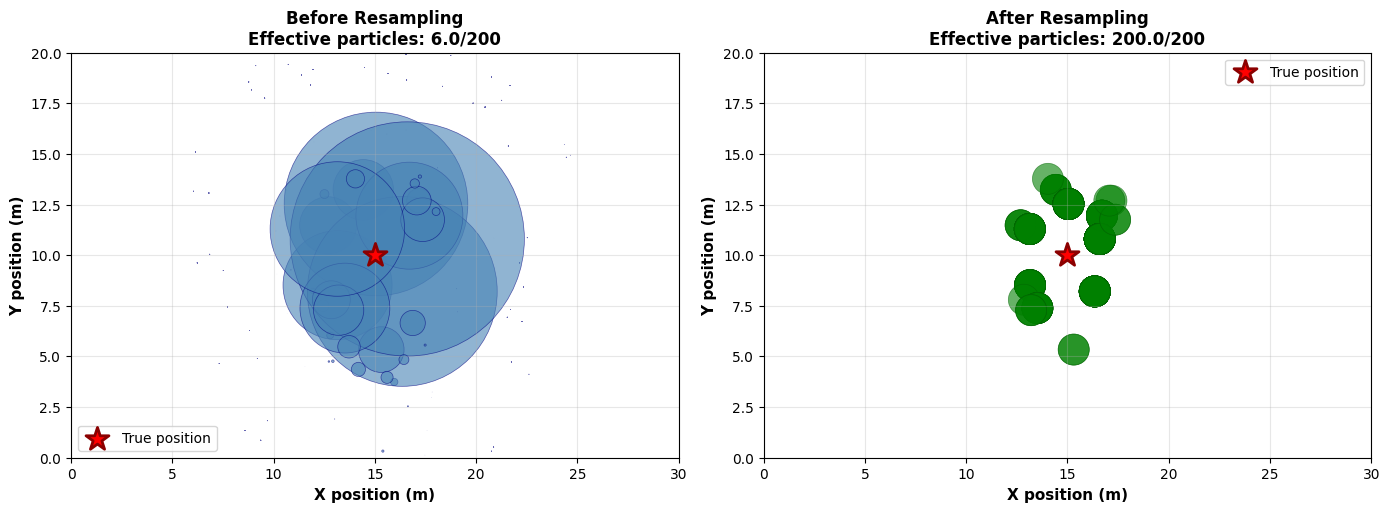


What happened:
  • Before: Only 6.0 particles had significant weight (degeneracy)
  • After: Back to 200.0 effective particles
  • Resampling duplicated high-weight particles and removed low-weight ones
  • This prevents the filter from wasting computation on unlikely hypotheses


In [ ]:
# ==========  Demo 4: Visualizing the Resampling Step ==========

# Create a scenario where particles degenerate
np.random.seed(123)
n_particles = 200

# Start with uniform particles
particles = create_uniform_particles((0, 30), (0, 20), n_particles)
weights = np.ones(n_particles) / n_particles

# Simulate several updates that cause degeneracy
true_pos = np.array([15., 10.])
landmarks = np.array([[0, 0], [30, 0]])

print("Simulating 5 update steps without resampling")
for i in range(5):
    # Measure
    z = np.array([np.linalg.norm(true_pos - lm) for lm in landmarks])
    # Update weights
    update(particles, weights, z, 2.0, landmarks)
    n_eff = neff(weights)
    print(f"  Step {i+1}: Effective particles = {n_eff:.1f}/{n_particles}")

# Visualize before and after resampling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Before resampling
sizes_before = weights * n_particles * 500
ax1.scatter(particles[:, 0], particles[:, 1], s=sizes_before, alpha=0.6, c='steelblue', edgecolors='navy', linewidth=0.5)
ax1.scatter(true_pos[0], true_pos[1], s=300, c='red', marker='*', edgecolors='darkred', linewidths=2, label='True position', zorder=10)
ax1.set_xlim(0, 30)
ax1.set_ylim(0, 20)
ax1.set_xlabel('X position (m)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Y position (m)', fontsize=11, fontweight='bold')
ax1.set_title(f'Before Resampling\nEffective particles: {neff(weights):.1f}/{n_particles}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# After resampling
indices = systematic_resample(weights)
particles_resampled = particles[indices]
weights_resampled = np.ones(n_particles) / n_particles

sizes_after = weights_resampled * n_particles * 500
ax2.scatter(particles_resampled[:, 0], particles_resampled[:, 1], s=sizes_after, alpha=0.6, c='green', edgecolors='darkgreen', linewidth=0.5)
ax2.scatter(true_pos[0], true_pos[1], s=300, c='red', marker='*', edgecolors='darkred', linewidths=2, label='True position', zorder=10)
ax2.set_xlim(0, 30)
ax2.set_ylim(0, 20)
ax2.set_xlabel('X position (m)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Y position (m)', fontsize=11, fontweight='bold')
ax2.set_title(f'After Resampling\nEffective particles: {neff(weights_resampled):.1f}/{n_particles}', fontsize=12, fontweight='bold')
ax2.legend()
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nWhat happened:")
print(f"  • Before: Only {neff(weights):.1f} particles had significant weight (degeneracy)")
print(f"  • After: Back to {neff(weights_resampled):.1f} effective particles")
print(f"  • Resampling duplicated high-weight particles and removed low-weight ones")
print(f"  • This prevents the filter from wasting computation on unlikely hypotheses")

## Why resampling matters

The visualization above demonstrates particle degeneracy, a key problem we discussed earlier in the tutorial. After several update steps, most particles had nearly zero weight, meaning only a few particles were doing all the work. The effective sample size dropped from 200 to just 6.

Resampling solves this by duplicating particles with high weights and discarding those with low weights. After resampling, all particles have equal weight again, and we're back to having 200 effective particles instead of just a handful.

This is why particle filters remain efficient even after many timesteps. Without resampling, we'd eventually be computing with mostly useless particles that contribute nothing to the estimate.

## Summary & what we learned 📚

Congratulations! You've just implemented and experimented with a complete particle filter. Let's connect everything back to class concepts and the research paper.

### Key concepts covered

**Particle filtering as Bayesian inference**
- Particles are samples from a probability distribution
- Predict step = prior distribution p(x_t | x_(t-1))
- Update step = Bayes' rule (posterior ∝ likelihood x prior)
- Resampling handles degeneracy

**The Markov property**

Future state depends only on current state plus control input: x(t+1) = x(t) + velocity*dt + noise. This is the foundation of our motion model.

**Diffusion and uncertainty**

Uncertainty grows during prediction (particles spread) and decreases when observations come in (particles concentrate). The balance depends on process versus measurement noise.

**Monte Carlo Approximation**

More particles give better accuracy but cost more computation. Convergence rate is O(1/√N), meaning diminishing returns (1000 particles aren't 10x better than 100).

### Connection to the Romeas et al. (2024) paper

The study found that 3D-MOT training improved tracking scores but showed **no transfer** to soccer performance or attention tests. Particle filtering helps explain why:

* **Tracking isn't everything:** our filter can track perfectly, but soccer requires tracking plus anticipation plus decision-making plus motor execution. 3D-MOT only trains one component.

* **Parameter dependence matters:** we saw that optimal parameters depend on task characteristics. 3D-MOT uses fixed sphere speeds in a controlled environment. Real soccer is dynamic with varying player speeds, occlusions, and deception. Training on one doesn't transfer to the other.

* **Representativeness is key:** the more tasks differ from the context, the more difficult the transfer becomes. 3D-MOT uses abstract spheres in VR. Soccer has real players with intentions and unpredictable movements. The state space is fundamentally different.

* **Perception-action coupling:** particle filtering is purely computational. Soccer requires tight perception-action coupling. Knowing where players are is different from knowing what to do about it.

### Broader implications

Particle filters are used in robotics (self-driving cars tracking pedestrians), computer vision (multi-object tracking), finance (market state tracking), and even neuroscience (models of how the brain tracks objects). But as the Romeas study shows, success in controlled environments doesn't automatically transfer to complex, real-world performance. The study challenges claims about domain-general cognitive training and highlights the importance of sport-specific training and validity in research.

Particle filtering shows why improving visual tracking ability in a controlled VR environment does not guarantee transfer to real soccer: the state dynamics, uncertainty patterns, and task constraints differ dramatically. This mirrors Romeas et al.'s finding that 3D-MOT gains do not translate into near or far transfer.

### Further Exploration

If you want to extend this, you could try:
- Multi-target tracking (track 4 of 8 players simultaneously, like 3D-MOT)
- Occlusion handling (what happens when landmarks are invisible)
- Adaptive noise (learn process noise from data)
- Different motion models (acceleration, turning, switching patterns)

And questions to also consider could be *how many particles does the human visual system use? Could we model human 3D-MOT performance with particle filters? What would make particle filtering useful for soccer coaching?*

### References

**Paper:**
Romeas, T., Goujat, M., Faubert, J., & Labbé, D. (2024). No transfer of 3D-Multiple Object Tracking training on game performance in soccer: A follow-up study. *Psychology of Sport & Exercise*, 76, 102770.